# NB07: Community Hotspot Profiles and Inferred Metabolic Interactions

**Goal**: For each SSO well, profile the dominant community members and infer potential metabolic interactions — syntrophy, cross-feeding, electron donor-acceptor coupling, and competition. Build a conceptual interaction model for each biogeochemical hotspot identified in NB04/NB06.

**Approach**: 
1. Profile top 15 genera per well with their known metabolisms
2. Identify co-occurring functional guilds (denitrifiers + iron reducers, syntrophs + methanogens, etc.)
3. Map interactions onto the plume model: which wells host cooperative vs competitive metabolic networks?
4. Compute guild co-occurrence across wells to identify spatially linked functional assemblages

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

GRID = {
    'SSO-U1': (2, 0), 'SSO-U2': (2, 1), 'SSO-U3': (2, 2),
    'SSO-M4': (1, 0), 'SSO-M5': (1, 1), 'SSO-M6': (1, 2),
    'SSO-L7': (0, 0), 'SSO-L8': (0, 1), 'SSO-L9': (0, 2),
}
WELL_ORDER = ['SSO-U1', 'SSO-U2', 'SSO-U3', 'SSO-M4', 'SSO-M5', 'SSO-M6',
              'SSO-L7', 'SSO-L8', 'SSO-L9']

sed = pd.read_parquet(DATA / 'sso_sediment_asv.parquet')
total_per_well = sed.groupby('location')['abundance'].sum()

# Build genus relative abundance per well
genus_well = (sed.dropna(subset=['genus'])
              .groupby(['location', 'genus'])['abundance'].sum()
              .reset_index())
genus_well['rel_pct'] = genus_well.apply(
    lambda r: r['abundance'] / total_per_well[r['location']] * 100, axis=1)

print("Data loaded")

Data loaded


## 1. Functional Guild Definitions

Assign each annotated genus to a metabolic guild. Guilds represent functional roles in the subsurface biogeochemical network — organisms within the same guild perform similar functions (potential competitors), while organisms in different guilds may be coupled through electron donor-acceptor relationships (potential syntrophs/cross-feeders).

In [2]:
# Assign genera to primary metabolic guilds
# Guild = the dominant metabolic mode that defines ecological role
GUILD_MAP = {
    # Denitrifiers (NO3- -> N2) — consume plume nitrate
    'denitrifier': ['Rhodanobacter', 'Castellaniella', 'Simplicispira', 'Zoogloea',
                    'Methyloversatilis', 'Hyphomicrobium', 'Sulfuritalea'],
    # Nitrifiers (NH4+ -> NO2-/NO3-) — regenerate nitrate
    'nitrifier': ['MND1', 'Candidatus Nitrosotalea', 'Nitrospira'],
    # Iron reducers (Fe3+ -> Fe2+) — key metal cycling
    'iron_reducer': ['Anaeromyxobacter', 'Geobacter', 'Rhodoferax'],
    # Iron oxidizers (Fe2+ -> Fe3+) — plume-front process
    'iron_oxidizer': ['Sideroxydans', 'Gallionella', 'Acidibacter'],
    # Sulfate reducers (SO4 -> H2S)
    'sulfate_reducer': ['Desulfobacca', 'Desulfovibrio', 'Desulfosporosinus'],
    # Sulfur oxidizers (H2S/S0 -> SO4)
    'sulfur_oxidizer': ['Arcobacter', 'Thiobacillus', 'Sulfuricurvum'],
    # Syntrophs (obligate partners for methanogenesis/anaerobic degradation)
    'syntroph': ['Syntrophus', 'Syntrophorhabdus', 'Pelotomaculum', 
                 'Candidatus Cloacimonas'],
    # Methane cyclers
    'methanotroph': ['Candidatus Methanoperedens', 'Methylobacterium', 'Methylotenera'],
    # Fermenters (complex C -> organic acids, H2, CO2)
    'fermenter': ['Spirochaeta', 'Paenisporosarcina', 'Anoxybacillus', 
                  'Trichococcus', 'Blautia'],
    # Aerobic heterotrophs (O2 + organic C)
    'aerobic_heterotroph': ['Pseudomonas', 'Sphingomonas', 'Massilia', 'Acinetobacter',
                            'Rhizomicrobium', 'Gordonia', 'Rhodococcus', 'Terrimonas',
                            'Candidatus Solibacter', 'Candidatus Omnitrophus',
                            'Comamonas', 'Duganella', 'Niastella', 'Gaiella', 'Afipia',
                            'Paenarthrobacter', 'Chujaibacter', 'Ferruginibacter'],
    # Predators
    'predator': ['Bdellovibrio'],
}

# Invert: genus -> guild
GENUS_GUILD = {}
for guild, genera in GUILD_MAP.items():
    for g in genera:
        GENUS_GUILD[g] = guild

# Known interaction types between guilds
GUILD_INTERACTIONS = {
    ('fermenter', 'syntroph'): 'cross-feeding: fermenters produce organic acids consumed by syntrophs',
    ('syntroph', 'sulfate_reducer'): 'syntrophic: syntrophs produce H2 consumed by sulfate reducers',
    ('syntroph', 'methanotroph'): 'syntrophic: H2/formate coupling in anaerobic methane oxidation',
    ('denitrifier', 'iron_reducer'): 'sequential: denitrifiers consume NO3-, creating conditions for Fe reduction',
    ('iron_oxidizer', 'iron_reducer'): 'iron cycle: oxidizers produce Fe3+, reducers regenerate Fe2+',
    ('sulfur_oxidizer', 'sulfate_reducer'): 'sulfur cycle: oxidizers produce SO4, reducers regenerate H2S',
    ('nitrifier', 'denitrifier'): 'nitrogen cycle: nitrifiers produce NO3- consumed by denitrifiers',
    ('aerobic_heterotroph', 'fermenter'): 'O2 gradient: aerobes deplete O2, creating anoxic niche for fermenters',
    ('fermenter', 'iron_reducer'): 'cross-feeding: fermenters produce organic acids as e-donors for Fe reduction',
    ('fermenter', 'sulfate_reducer'): 'cross-feeding: fermenters produce H2/acetate for sulfate reduction',
    ('predator', 'aerobic_heterotroph'): 'predation: Bdellovibrio preys on Gram-negative heterotrophs',
}

print(f"Guild map: {len(GENUS_GUILD)} genera in {len(GUILD_MAP)} guilds")
print(f"Interaction rules: {len(GUILD_INTERACTIONS)} known guild-guild interactions")

Guild map: 53 genera in 11 guilds
Interaction rules: 11 known guild-guild interactions


## 2. Well-by-Well Hotspot Profiles

For each well, show the top genera, their guilds, and the guild composition. Then identify which metabolic interactions are possible at each location.

In [3]:
# Build guild abundance per well
guild_well = pd.DataFrame(0.0, index=WELL_ORDER, columns=sorted(GUILD_MAP.keys()))

for well in WELL_ORDER:
    wdata = genus_well[genus_well['location'] == well]
    for _, row in wdata.iterrows():
        guild = GENUS_GUILD.get(row['genus'])
        if guild:
            guild_well.loc[well, guild] += row['rel_pct']

# Print hotspot profile for each well
hotspot_names = {
    'SSO-U1': 'Iron Reduction Zone',
    'SSO-U2': 'Sulfate Reduction Zone', 
    'SSO-U3': 'Plume Entry (Fe/N Oxidation)',
    'SSO-M4': 'Methanotrophy/Sulfur Oxidation',
    'SSO-M5': 'Denitrification Hotspot (Mixing Zone)',
    'SSO-M6': 'Anaerobic Core (Plume Center)',
    'SSO-L7': 'Plume Corridor Terminus',
    'SSO-L8': 'Aerobic Heterotrophy Zone',
    'SSO-L9': 'Fermentation Terminus',
}

all_profiles = []
for well in WELL_ORDER:
    wdata = genus_well[genus_well['location'] == well].sort_values('rel_pct', ascending=False)
    top15 = wdata.head(15)
    
    print(f"\n{'='*70}")
    print(f"  {well} — {hotspot_names[well]}")
    print(f"{'='*70}")
    
    # Guild composition
    guilds = guild_well.loc[well].sort_values(ascending=False)
    guilds_present = guilds[guilds > 0]
    print(f"\n  Guild composition (annotated genera only):")
    for guild, pct in guilds_present.items():
        print(f"    {guild:<25} {pct:>5.2f}%")
    
    # Top genera with guilds
    print(f"\n  Top 15 genera:")
    print(f"    {'Genus':<35} {'%':>6} {'Guild':<25}")
    print(f"    {'-'*70}")
    for _, row in top15.iterrows():
        guild = GENUS_GUILD.get(row['genus'], '—')
        print(f"    {row['genus']:<35} {row['rel_pct']:>5.2f}% {guild:<25}")
    
    # Identify active interactions at this well
    active_guilds = set(guilds_present.index)
    interactions = []
    for (g1, g2), desc in GUILD_INTERACTIONS.items():
        if g1 in active_guilds and g2 in active_guilds:
            strength = min(guilds_present[g1], guilds_present[g2])
            interactions.append((g1, g2, desc, strength))
    
    if interactions:
        interactions.sort(key=lambda x: -x[3])
        print(f"\n  Inferred metabolic interactions:")
        for g1, g2, desc, strength in interactions:
            print(f"    {g1} ↔ {g2} ({strength:.2f}%)")
            print(f"      → {desc}")
    
    for _, row in top15.iterrows():
        all_profiles.append({
            'well': well, 'genus': row['genus'], 
            'rel_pct': row['rel_pct'], 'guild': GENUS_GUILD.get(row['genus'], 'unassigned')
        })

pd.DataFrame(all_profiles).to_csv(DATA / 'hotspot_profiles.csv', index=False)
guild_well.to_csv(DATA / 'guild_composition.csv')


  SSO-U1 — Iron Reduction Zone

  Guild composition (annotated genera only):
    aerobic_heterotroph        9.63%
    fermenter                  2.83%
    denitrifier                2.79%
    iron_reducer               2.34%
    sulfur_oxidizer            1.25%
    methanotroph               0.73%
    sulfate_reducer            0.54%
    syntroph                   0.48%
    nitrifier                  0.46%
    predator                   0.31%
    iron_oxidizer              0.05%

  Top 15 genera:
    Genus                                    % Guild                    
    ----------------------------------------------------------------------
    Massilia                             3.12% aerobic_heterotroph      
    Anaeromyxobacter                     2.23% iron_reducer             
    Arcobacter                           1.15% sulfur_oxidizer          
    Pseudomonas                          1.04% aerobic_heterotroph      
    Candidatus Accumulibacter            0.98% —         

## 3. Guild Composition Across the Grid

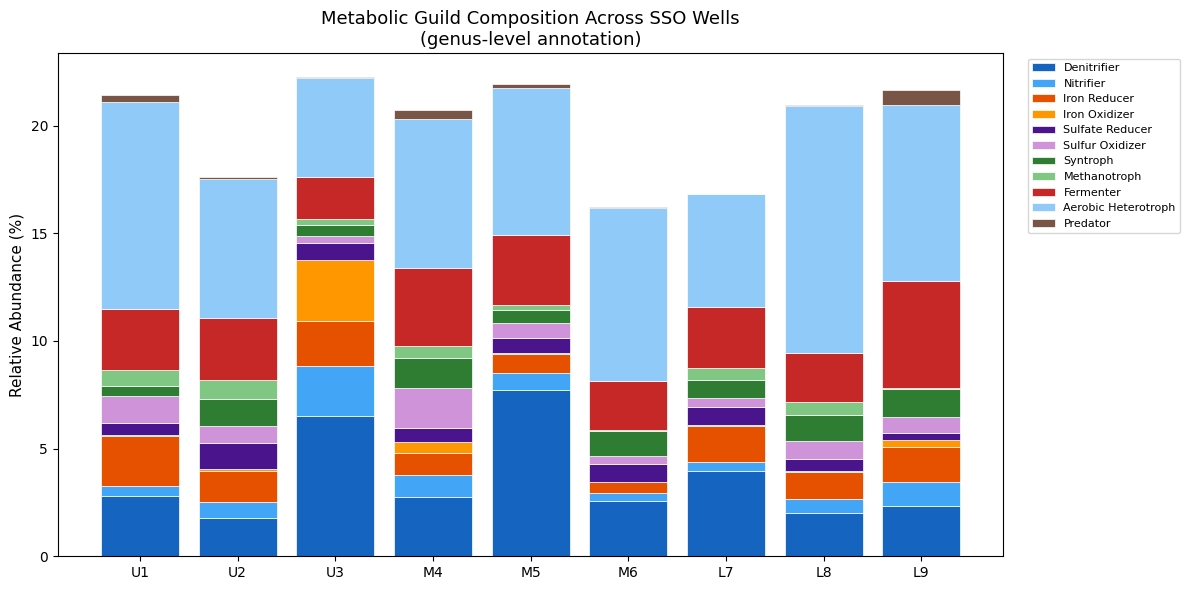

Saved: figures/guild_composition_bars.png


In [4]:
# Stacked bar: guild composition per well
guild_order = ['denitrifier', 'nitrifier', 'iron_reducer', 'iron_oxidizer',
               'sulfate_reducer', 'sulfur_oxidizer', 'syntroph', 'methanotroph',
               'fermenter', 'aerobic_heterotroph', 'predator']
guild_colors = {
    'denitrifier': '#1565C0', 'nitrifier': '#42A5F5', 
    'iron_reducer': '#E65100', 'iron_oxidizer': '#FF9800',
    'sulfate_reducer': '#4A148C', 'sulfur_oxidizer': '#CE93D8',
    'syntroph': '#2E7D32', 'methanotroph': '#81C784',
    'fermenter': '#C62828', 'aerobic_heterotroph': '#90CAF9',
    'predator': '#795548',
}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(9)
x = np.arange(9)

for guild in guild_order:
    vals = guild_well.loc[WELL_ORDER, guild].values.astype(float)
    if vals.sum() > 0:
        ax.bar(x, vals, bottom=bottom, label=guild.replace('_', ' ').title(),
               color=guild_colors[guild], edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([w.replace('SSO-', '') + '\n' + hotspot_names['SSO-' + w.replace('SSO-','')].split('(')[0].strip()
                     if 'SSO-' in w else w.replace('SSO-','') 
                     for w in WELL_ORDER], fontsize=8, rotation=0)
# Simpler labels
ax.set_xticks(x)
labels = [f"{w.replace('SSO-','')}" for w in WELL_ORDER]
ax.set_xticklabels(labels, fontsize=10)

ax.set_ylabel('Relative Abundance (%)', fontsize=11)
ax.set_title('Metabolic Guild Composition Across SSO Wells\n(genus-level annotation)', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'guild_composition_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/guild_composition_bars.png")

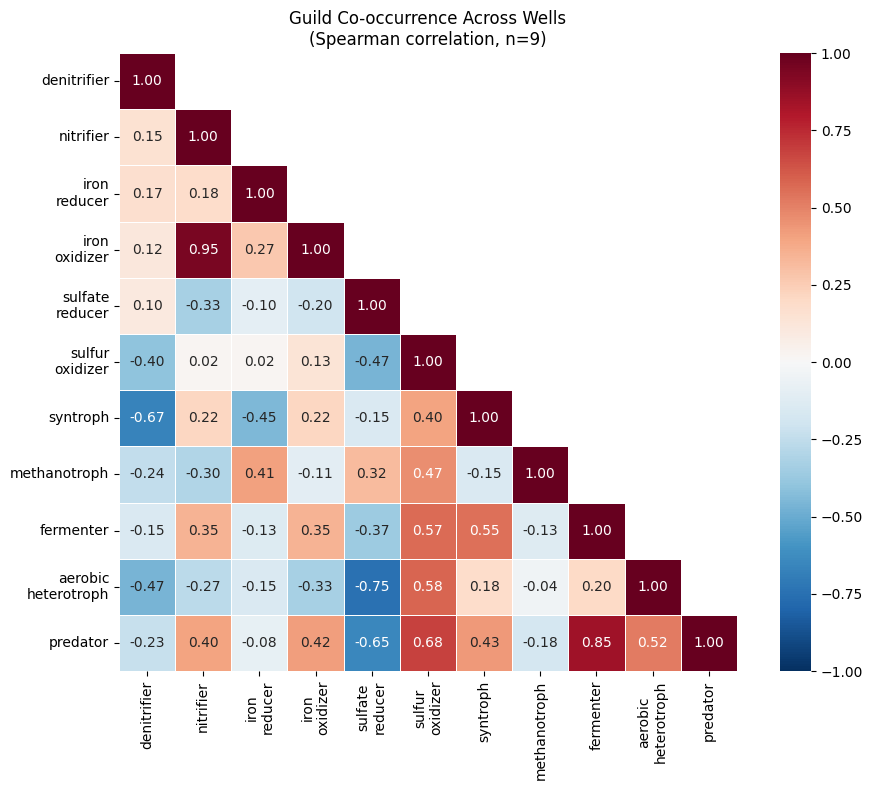

Saved: figures/guild_cooccurrence.png

Strong guild co-occurrences (|rho| > 0.5):
  denitrifier × syntroph: rho=-0.67 (exclude)
    Known: no known direct interaction
  nitrifier × iron_oxidizer: rho=+0.95 (co-occur)
    Known: no known direct interaction
  sulfate_reducer × aerobic_heterotroph: rho=-0.75 (exclude)
    Known: no known direct interaction
  sulfate_reducer × predator: rho=-0.65 (exclude)
    Known: no known direct interaction
  sulfur_oxidizer × fermenter: rho=+0.57 (co-occur)
    Known: no known direct interaction
  sulfur_oxidizer × aerobic_heterotroph: rho=+0.58 (co-occur)
    Known: no known direct interaction
  sulfur_oxidizer × predator: rho=+0.68 (co-occur)
    Known: no known direct interaction
  syntroph × fermenter: rho=+0.55 (co-occur)
    Known: cross-feeding: fermenters produce organic acids consumed by syntrophs
  fermenter × predator: rho=+0.85 (co-occur)
    Known: no known direct interaction
  aerobic_heterotroph × predator: rho=+0.52 (co-occur)
    Know

In [5]:
# Guild co-occurrence heatmap: which guilds appear together across wells?
# Spearman correlation of guild abundances across the 9 wells
guild_present = guild_well[guild_order].loc[WELL_ORDER]
guild_present = guild_present.loc[:, guild_present.sum() > 0]  # drop empty guilds

guild_corr = guild_present.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(guild_corr, dtype=bool), k=1)
sns.heatmap(guild_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            xticklabels=[g.replace('_', '\n') for g in guild_corr.columns],
            yticklabels=[g.replace('_', '\n') for g in guild_corr.index])
ax.set_title('Guild Co-occurrence Across Wells\n(Spearman correlation, n=9)', fontsize=12)

plt.tight_layout()
plt.savefig(FIG / 'guild_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/guild_cooccurrence.png")

# Highlight strong co-occurrences and anti-correlations
print("\nStrong guild co-occurrences (|rho| > 0.5):")
for i, g1 in enumerate(guild_corr.columns):
    for j, g2 in enumerate(guild_corr.columns):
        if i < j:
            rho = guild_corr.loc[g1, g2]
            if abs(rho) > 0.5:
                direction = "co-occur" if rho > 0 else "exclude"
                interaction = GUILD_INTERACTIONS.get((g1, g2)) or GUILD_INTERACTIONS.get((g2, g1)) or "no known direct interaction"
                print(f"  {g1} × {g2}: rho={rho:+.2f} ({direction})")
                print(f"    Known: {interaction}")